<a href="https://colab.research.google.com/github/Edwuar671/ProjectP2/blob/main/etl_pipeline_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 Pipeline ETL Automatizado en Python
## Extracción y Procesamiento de Datos desde la API REST Countries

---

| Campo | Detalle |
|---|---|
| **Asignatura** | Programación II — 2026 |
| **Autores** | Freddy Santiago Hernández Gelves · Edwuar Andrés Niño Portilla · Raúl Andrés Vesga Neira |
| **Fuente de datos** | [REST Countries API](https://restcountries.com/v3.1/all) |
| **Stack** | Python 3.11 · Pandas 2.x · Requests · Matplotlib · Seaborn |

---

## Descripción general

Este notebook implementa un **pipeline ETL** (Extract → Transform → Load) completo que:

1. **Extrae** datos de todos los países del mundo en formato JSON desde una API pública.
2. **Transforma** los datos crudos: limpieza, normalización de tipos, enriquecimiento con columnas derivadas y análisis estadístico.
3. **Carga** el dataset procesado en un archivo CSV listo para análisis.
4. **Visualiza** patrones demográficos y geográficos del dataset resultante.
5. **Valida** la lógica de cada etapa mediante pruebas unitarias.

> **Ejecución**: Ejecutar las celdas en orden secuencial (`Shift + Enter`).  
> Requiere conexión a Internet para la etapa de extracción.


---
## 0. Instalación y verificación de dependencias

Antes de ejecutar el pipeline, verificamos que las librerías requeridas estén instaladas.  
Si no lo están, se instalan automáticamente en el entorno activo.


In [ ]:
# ─── 0.1 Instalación automática de dependencias ────────────────────────────
import subprocess, sys

REQUIRED = ["requests", "pandas", "matplotlib", "seaborn"]

for pkg in REQUIRED:
    try:
        __import__(pkg)
        print(f"  ✅  {pkg} ya instalado")
    except ImportError:
        print(f"  📦  Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  ✅  {pkg} instalado correctamente")


  ✅  requests ya instalado
  ✅  pandas ya instalado
  ✅  matplotlib ya instalado
  ✅  seaborn ya instalado


---
## 1. Importaciones y configuración global

Cargamos todas las librerías necesarias y configuramos el sistema de logging y los parámetros globales del pipeline.

| Librería | Propósito |
|---|---|
| `requests` | Conexión HTTP a la API REST |
| `pandas` | Manipulación y transformación de datos |
| `logging` | Registro estructurado de eventos |
| `matplotlib` / `seaborn` | Visualización de datos |
| `unittest` | Pruebas unitarias de las etapas ETL |


In [ ]:
# ─── 1.1 Librerías ─────────────────────────────────────────────────────────
import requests
import pandas as pd
import logging
import os
import unittest
from datetime import datetime
from io import StringIO

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ─── 1.2 Configuración del logger ──────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("etl_pipeline")

# ─── 1.3 Parámetros globales ───────────────────────────────────────────────
API_URL = (
    "https://restcountries.com/v3.1/all?"
    "fields=name,capital,region,subregion,population,"
    "area,cca2,cca3,independent,landlocked"
)
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "countries_data.csv")

# Estilo de gráficas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})

print("✅ Configuración lista.")
print(f"   API URL  : {API_URL}")
print(f"   Salida   : {OUTPUT_FILE}")


✅ Configuración lista.
   API URL  : https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,cca2,cca3,independent,landlocked
   Salida   : output/countries_data.csv


---
## 2. Etapa 1 — EXTRACT (Extracción)

### ¿Qué hace esta etapa?

La función `extract()` realiza una solicitud **GET** al endpoint de la API pública **REST Countries**.  
La API devuelve una lista JSON con ~250 objetos, cada uno representando un país con ~50 campos.

```
GET https://restcountries.com/v3.1/all
```

**Manejo de errores implementado:**
- `timeout=15 s` → evita bloqueos por lentitud de red.
- `raise_for_status()` → lanza `HTTPError` si el código HTTP indica falla (4xx / 5xx).
- El orquestador captura `RequestException` para registrar el error sin crashear.


In [ ]:
# ─── 2.1 Función de extracción ─────────────────────────────────────────────
def extract(url: str) -> list[dict]:
    """
    Extrae datos en formato JSON desde la API pública REST Countries.

    Parameters
    ----------
    url : str
        URL del endpoint de la API REST.

    Returns
    -------
    list[dict]
        Lista de diccionarios con los datos crudos de cada país.

    Raises
    ------
    requests.HTTPError
        Si la respuesta HTTP tiene un código de error (4xx / 5xx).
    requests.exceptions.RequestException
        Si falla la conexión a la red o se agota el tiempo de espera.
    """
    logger.info("Iniciando extracción de datos desde: %s", url)
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    data = response.json()
    logger.info("Extracción exitosa: %d registros obtenidos.", len(data))
    return data


# ─── 2.2 Ejecución ─────────────────────────────────────────────────────────
raw_data = extract(API_URL)

print(f"\n📦 Registros extraídos : {len(raw_data)}")
print(f"🔑 Campos disponibles  : {len(raw_data[0].keys())}")
print(f"\n🔍 Vista previa — campos de un país (índice 0):")
for campo in list(raw_data[0].keys())[:12]:
    print(f"   • {campo}: {str(raw_data[0][campo])[:60]}")



📦 Registros extraídos : 250
🔑 Campos disponibles  : 10

🔍 Vista previa — campos de un país (índice 0):
   • name: {'common': 'Anguilla', 'official': 'Anguilla', 'nativeName':
   • cca2: AI
   • cca3: AIA
   • independent: False
   • capital: ['The Valley']
   • region: Americas
   • subregion: Caribbean
   • landlocked: False
   • area: 91.0
   • population: 16010


---
## 3. Etapa 2 — TRANSFORM (Transformación)

### ¿Qué hace esta etapa?

Esta es la etapa más compleja del pipeline. La función `transform()` convierte la lista cruda de diccionarios en un **DataFrame limpio y normalizado** listo para análisis.

**Pasos aplicados en orden:**

| # | Operación | Detalle |
|---|---|---|
| 1 | Selección de campos | Se eligen 14 campos relevantes de los ~50 disponibles |
| 2 | Limpieza de nulos | Se eliminan registros sin `nombre_comun` o `region` |
| 3 | Normalización de texto | `.strip()` + `.title()` en columnas de cadena |
| 4 | Conversión de tipos | `poblacion → Int64` (soporta NA), `area_km2 → float64` |
| 5 | Columna derivada | `densidad_hab_km2 = poblacion / area_km2` |
| 6 | Ordenamiento | Descendente por `poblacion` |

**Funciones auxiliares:**
- `_extraer_moneda()` — accede al primer valor del diccionario `currencies`.
- `_extraer_idiomas()` — concatena todos los idiomas en una cadena legible.


In [ ]:
# ─── 3.1 Funciones auxiliares ──────────────────────────────────────────────
def _extraer_moneda(currencies: dict) -> str | None:
    """
    Extrae el nombre de la primera moneda del diccionario de monedas.

    Parameters
    ----------
    currencies : dict
        Diccionario de monedas con estructura {código: {name, symbol}}.

    Returns
    -------
    str | None
        Nombre de la primera moneda, o None si el diccionario está vacío.

    Examples
    --------
    >>> _extraer_moneda({"USD": {"name": "United States dollar", "symbol": "$"}})
    'United States dollar'
    >>> _extraer_moneda({})
    None
    """
    if not currencies:
        return None
    primera = next(iter(currencies.values()), {})
    return primera.get("name")


def _extraer_idiomas(languages: dict) -> str | None:
    """
    Concatena todos los idiomas oficiales en una cadena separada por comas.

    Parameters
    ----------
    languages : dict
        Diccionario {código_idioma: nombre_idioma}.

    Returns
    -------
    str | None
        Cadena con los nombres de idiomas, o None si el dict está vacío.

    Examples
    --------
    >>> _extraer_idiomas({"es": "Spanish", "en": "English"})
    'Spanish, English'
    >>> _extraer_idiomas({})
    None
    """
    if not languages:
        return None
    return ", ".join(languages.values())


In [ ]:
# ─── 3.2 Función de transformación ─────────────────────────────────────────
def transform(raw_data: list[dict]) -> pd.DataFrame:
    """
    Transforma los datos crudos de la API en un DataFrame limpio y normalizado.

    Aplica selección de campos, limpieza de nulos, normalización de texto,
    conversión de tipos y generación de columna derivada de densidad poblacional.

    Parameters
    ----------
    raw_data : list[dict]
        Lista de diccionarios con los datos crudos de la API.

    Returns
    -------
    pd.DataFrame
        DataFrame con 15 columnas limpias, ordenado por población descendente.
        Columnas: nombre_comun, nombre_oficial, region, subregion, capital,
        poblacion, area_km2, codigo_alpha2, codigo_alpha3, independiente,
        pais_sin_salida_mar, moneda, idiomas, continentes, densidad_hab_km2.
    """
    logger.info("Iniciando transformación de datos...")

    # ── Paso 1: Selección de campos ────────────────────────────────────────
    registros = []
    for pais in raw_data:
        registro = {
            "nombre_comun":        pais.get("name", {}).get("common"),
            "nombre_oficial":      pais.get("name", {}).get("official"),
            "region":              pais.get("region"),
            "subregion":           pais.get("subregion"),
            "capital":             pais.get("capital")[0] if pais.get("capital") else None,
            "poblacion":           pais.get("population"),
            "area_km2":            pais.get("area"),
            "codigo_alpha2":       pais.get("cca2"),
            "codigo_alpha3":       pais.get("cca3"),
            "independiente":       pais.get("independent"),
            "pais_sin_salida_mar": pais.get("landlocked"),
            "moneda":              _extraer_moneda(pais.get("currencies", {})),
            "idiomas":             _extraer_idiomas(pais.get("languages", {})),
            "continentes":         ", ".join(pais.get("continents", [])),
        }
        registros.append(registro)

    df = pd.DataFrame(registros)

    # ── Paso 2: Limpieza de registros con nulos en campos clave ───────────
    registros_antes = len(df)
    df.dropna(subset=["nombre_comun", "region"], inplace=True)
    eliminados = registros_antes - len(df)
    logger.info("Registros eliminados por valores nulos en campos clave: %d", eliminados)

    # ── Paso 3: Normalización de columnas de texto ────────────────────────
    cols_texto = ["nombre_comun", "nombre_oficial", "region", "subregion", "capital"]
    for col in cols_texto:
        if col in df.columns:
            df[col] = df[col].str.strip().str.title()

    # ── Paso 4: Conversión de tipos ───────────────────────────────────────
    df["poblacion"] = pd.to_numeric(df["poblacion"], errors="coerce").astype("Int64")
    df["area_km2"]  = pd.to_numeric(df["area_km2"],  errors="coerce")

    # ── Paso 5: Columna derivada — densidad poblacional ───────────────────
    df["densidad_hab_km2"] = (df["poblacion"] / df["area_km2"]).round(2)

    # ── Paso 6: Ordenamiento descendente por población ────────────────────
    df.sort_values("poblacion", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    logger.info(
        "Transformación completada: %d registros, %d columnas.",
        len(df), len(df.columns)
    )
    return df


# ─── 3.3 Ejecución ─────────────────────────────────────────────────────────
df = transform(raw_data)

print(f"\n📊 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"🔍 Tipos de datos:\n{df.dtypes.to_string()}")
print(f"\n🌍 Vista previa (Top 10 por población):")
df[["nombre_comun", "region", "poblacion", "area_km2", "densidad_hab_km2"]].head(10)



📊 Dimensiones del dataset: 250 filas × 15 columnas
🔍 Tipos de datos:
nombre_comun            object
nombre_oficial          object
region                  object
subregion               object
capital                 object
poblacion                Int64
area_km2               float64
codigo_alpha2           object
codigo_alpha3           object
independiente             bool
pais_sin_salida_mar       bool
moneda                  object
idiomas                 object
continentes             object
densidad_hab_km2       Float64

🌍 Vista previa (Top 10 por población):


,nombre_comun,region,poblacion,area_km2,densidad_hab_km2
0,India,Asia,1417492000,3287263.0,431.21
1,China,Asia,1408280000,9706961.0,145.08
2,United States,Americas,340110988,9525067.0,35.71
3,Indonesia,Asia,284438782,1904569.0,149.35
4,Pakistan,Asia,241499431,796095.0,303.36
5,Nigeria,Africa,223800000,923768.0,242.27
6,Brazil,Americas,213421037,8515767.0,25.06
7,Bangladesh,Asia,169828911,147570.0,1150.84
8,Russia,Europe,146028325,17098246.0,8.54
9,Mexico,Americas,130575786,1964375.0,66.47


---
## 4. Análisis Exploratorio del Dataset (EDA)

Una vez transformados los datos, realizamos un análisis estadístico y visual para comprender la distribución y calidad del dataset generado.


In [ ]:
# ─── 4.1 Estadísticas descriptivas ─────────────────────────────────────────
print("=" * 60)
print("  ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas")
print("=" * 60)
df[["poblacion", "area_km2", "densidad_hab_km2"]].describe().round(2)


  ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas


,poblacion,area_km2,densidad_hab_km2
count,250.0,250.00,250.0
mean,32077981.84,601038.85,436.93
std,131965523.43,1912575.36,2031.54
min,0.0,0.49,0.0
25%,223354.25,1194.25,29.33
50%,5279123.0,64929.50,88.06
75%,20371664.25,384150.50,234.39
max,1417492000.0,17098246.00,22863.33


In [ ]:
# ─── 4.2 Análisis de valores nulos ─────────────────────────────────────────
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "% del total": pct})
resumen_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0].sort_values("Nulos", ascending=False)

if resumen_nulos.empty:
    print("✅ No hay valores nulos en columnas clave.")
else:
    print("⚠️  Columnas con valores nulos:")
    print(resumen_nulos.to_string())


⚠️  Columnas con valores nulos:
         Nulos  % del total
moneda     250        100.0
idiomas    250        100.0
capital      4          1.6


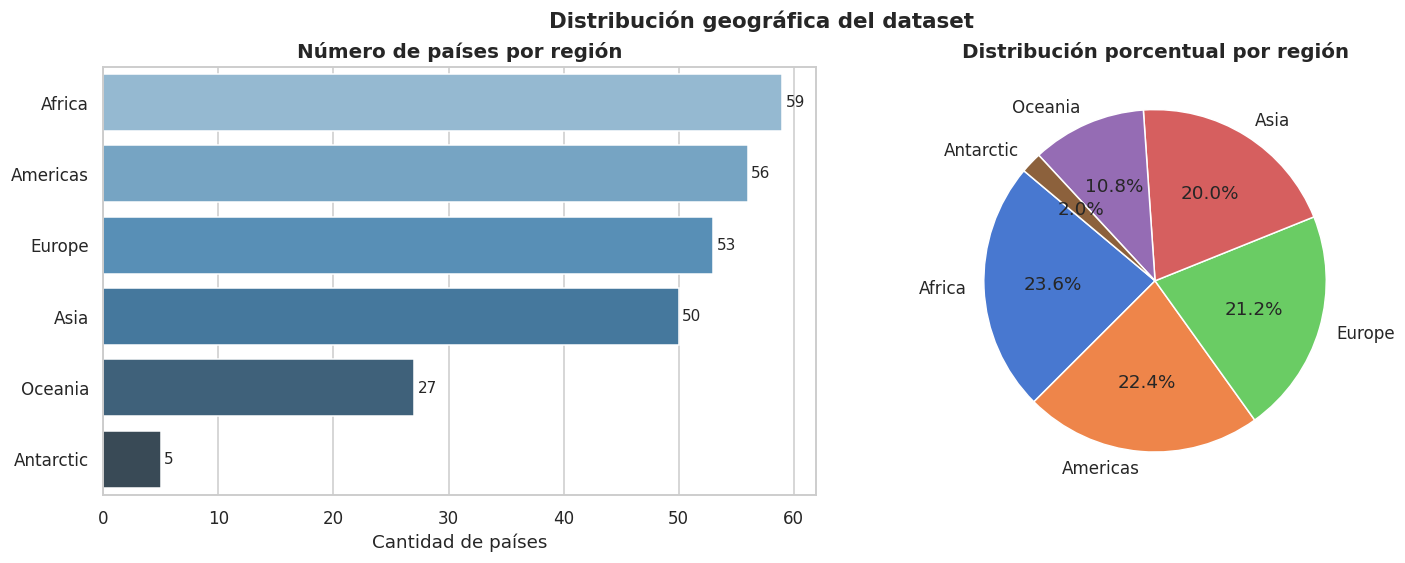

✅ Gráfica guardada en output/grafica_regiones.png


In [ ]:
# ─── 4.3 Países por región ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras: cantidad de países por región
conteo_region = df["region"].value_counts()
sns.barplot(
    x=conteo_region.values, y=conteo_region.index,
    palette="Blues_d", ax=axes[0]
)
axes[0].set_title("Número de países por región", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de países")
axes[0].set_ylabel("")
for i, v in enumerate(conteo_region.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=10)

# Gráfico de torta: distribución porcentual
axes[1].pie(
    conteo_region.values,
    labels=conteo_region.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("muted", len(conteo_region))
)
axes[1].set_title("Distribución porcentual por región", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.suptitle("Distribución geográfica del dataset", y=1.02, fontsize=14, fontweight="bold")
plt.savefig("output/grafica_regiones.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Gráfica guardada en output/grafica_regiones.png")


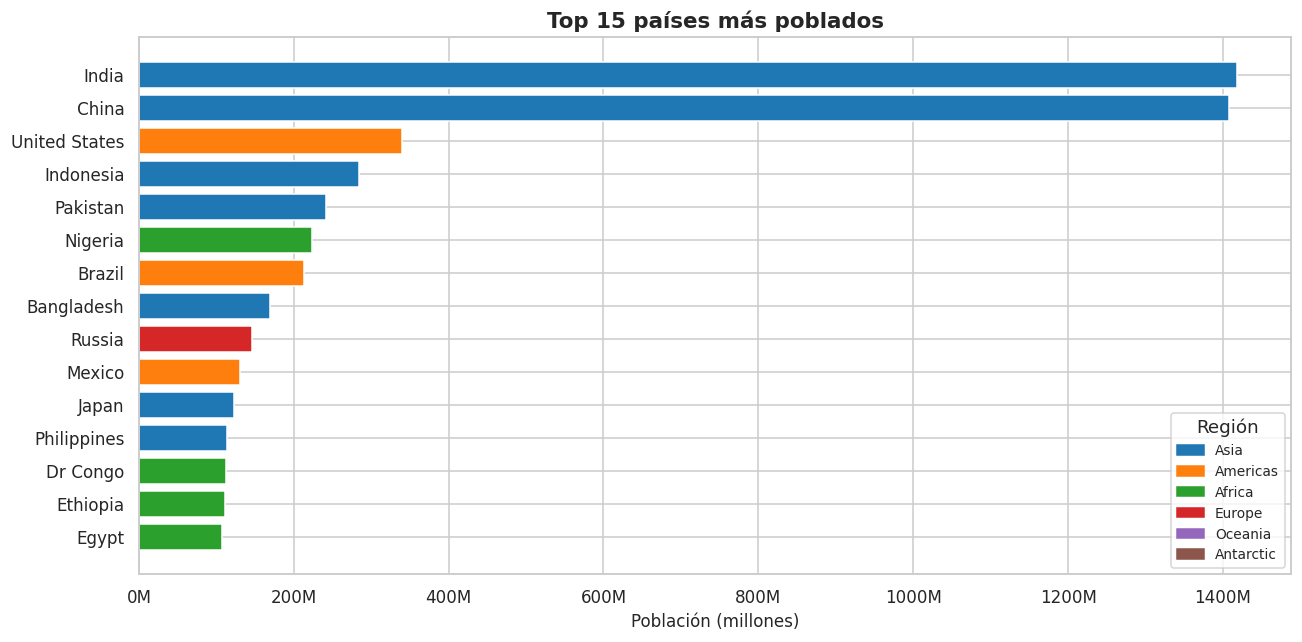

✅ Gráfica guardada en output/grafica_top15_poblacion.png


In [ ]:
# ─── 4.4 Top 15 países más poblados ────────────────────────────────────────
top15_pob = df.nlargest(15, "poblacion")[["nombre_comun", "poblacion", "region"]]

fig, ax = plt.subplots(figsize=(12, 6))
paleta = sns.color_palette("tab10", n_colors=df["region"].nunique())
colores_region = {r: paleta[i] for i, r in enumerate(df["region"].unique())}

barras = ax.barh(
    top15_pob["nombre_comun"][::-1],
    top15_pob["poblacion"][::-1] / 1_000_000,
    color=[colores_region[r] for r in top15_pob["region"][::-1]]
)

ax.set_xlabel("Población (millones)", fontsize=11)
ax.set_title("Top 15 países más poblados", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))

# Leyenda de regiones
from matplotlib.patches import Patch
handles = [Patch(color=colores_region[r], label=r) for r in colores_region]
ax.legend(handles=handles, title="Región", loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("output/grafica_top15_poblacion.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Gráfica guardada en output/grafica_top15_poblacion.png")


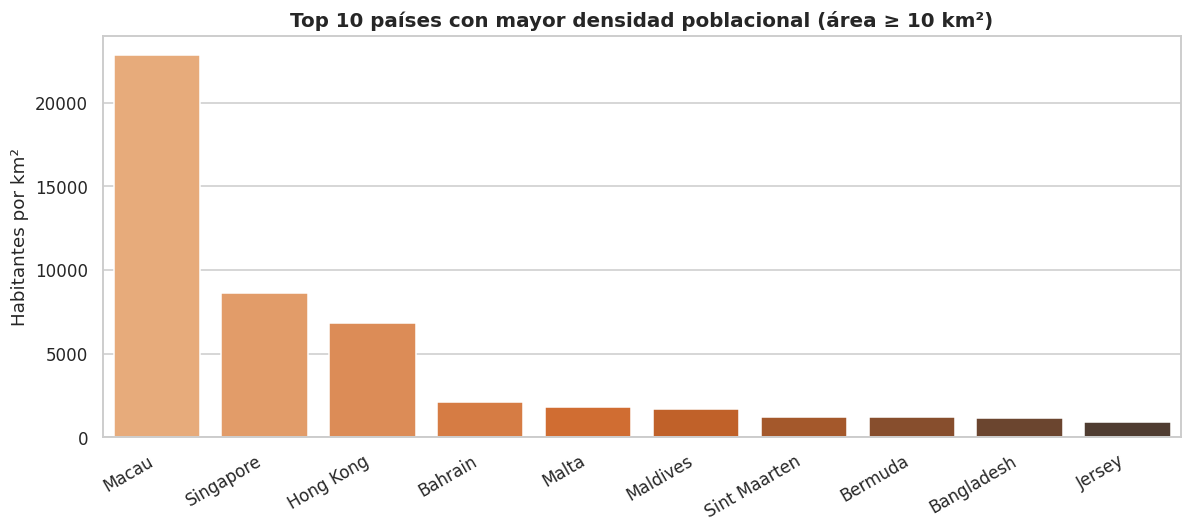

✅ Gráfica guardada en output/grafica_densidad.png


In [ ]:
# ─── 4.5 Top 10 países con mayor densidad poblacional ──────────────────────
# (excluimos microestados con área < 10 km² para evitar outliers extremos)
df_filtrado = df[df["area_km2"] >= 10].copy()
top10_densidad = df_filtrado.nlargest(10, "densidad_hab_km2")[
    ["nombre_comun", "densidad_hab_km2", "poblacion", "area_km2"]
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=top10_densidad,
    x="nombre_comun", y="densidad_hab_km2",
    palette="Oranges_d", ax=ax
)
ax.set_title("Top 10 países con mayor densidad poblacional (área ≥ 10 km²)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Habitantes por km²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("output/grafica_densidad.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Gráfica guardada en output/grafica_densidad.png")


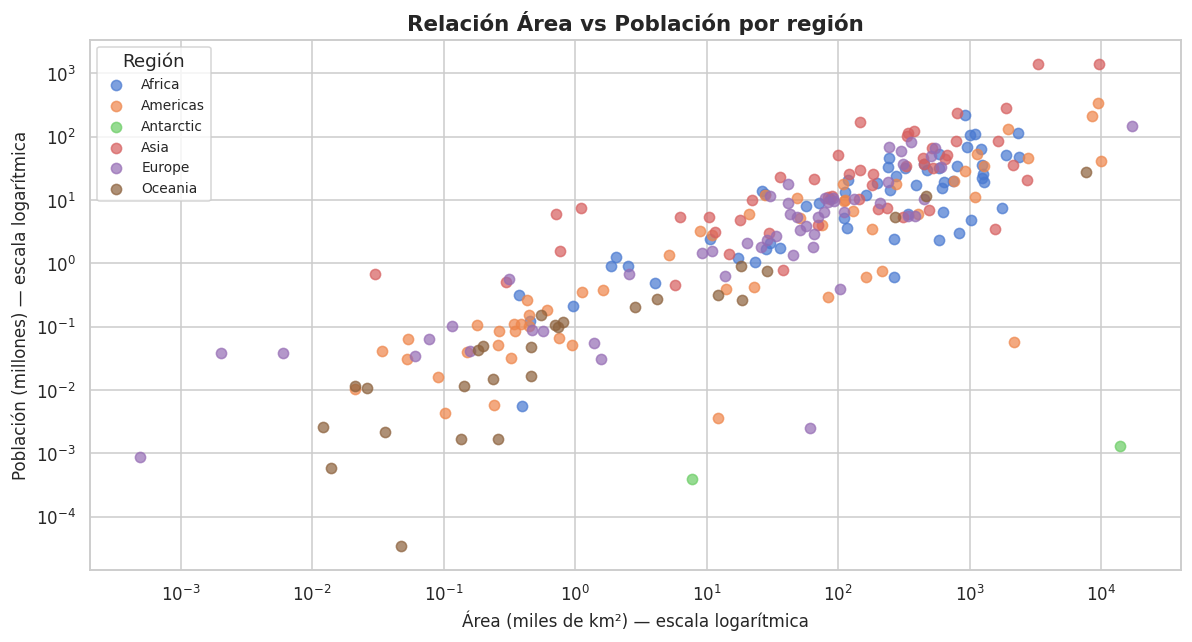

✅ Gráfica guardada en output/grafica_area_vs_poblacion.png


In [ ]:
# ─── 4.6 Dispersión: Área vs Población por región ──────────────────────────
df_plot = df[(df["poblacion"] > 0) & (df["area_km2"] > 0)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
for region, grupo in df_plot.groupby("region"):
    ax.scatter(
        grupo["area_km2"] / 1_000,
        grupo["poblacion"] / 1_000_000,
        label=region, alpha=0.7, s=45
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Área (miles de km²) — escala logarítmica", fontsize=11)
ax.set_ylabel("Población (millones) — escala logarítmica", fontsize=11)
ax.set_title("Relación Área vs Población por región", fontsize=14, fontweight="bold")
ax.legend(title="Región", fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("output/grafica_area_vs_poblacion.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Gráfica guardada en output/grafica_area_vs_poblacion.png")


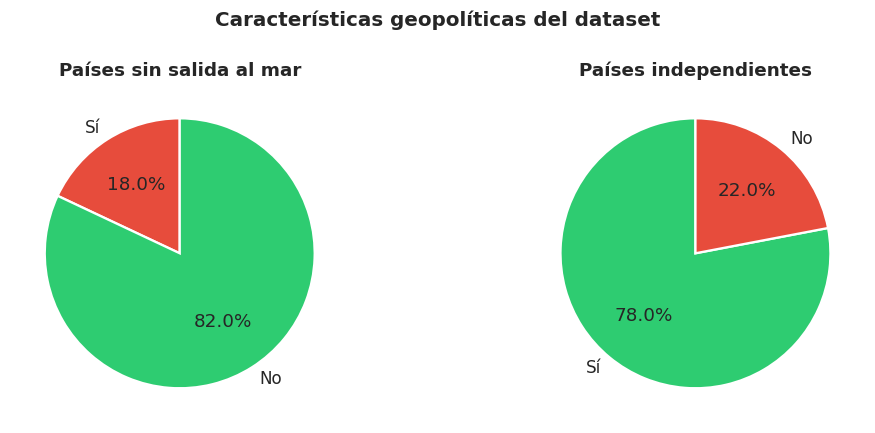

  • Países sin salida al mar : 45 / 250
  • Países independientes    : 195 / 250


In [ ]:
# ─── 4.7 Países sin salida al mar e independientes ─────────────────────────
total = len(df)
sin_mar      = df["pais_sin_salida_mar"].sum()
independientes = df["independiente"].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, valor, total_v, titulo, colores in [
    (axes[0], sin_mar,       total, "Países sin salida al mar",  ["#e74c3c", "#2ecc71"]),
    (axes[1], independientes, total, "Países independientes",    ["#2ecc71", "#e74c3c"]),
]:
    ax.pie(
        [valor, total_v - valor],
        labels=["Sí", "No"],
        colors=colores,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5)
    )
    ax.set_title(titulo, fontsize=12, fontweight="bold")

plt.suptitle("Características geopolíticas del dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("output/grafica_geopolitica.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"  • Países sin salida al mar : {int(sin_mar)} / {total}")
print(f"  • Países independientes    : {int(independientes)} / {total}")


---
## 5. Etapa 3 — LOAD (Carga)

### ¿Qué hace esta etapa?

La función `load()` persiste el DataFrame transformado en un archivo **CSV con codificación UTF-8 con BOM** (`utf-8-sig`).

**¿Por qué `utf-8-sig`?**  
Esta codificación añade un marcador de orden de bytes (BOM) al inicio del archivo, lo que permite que **Microsoft Excel** reconozca automáticamente caracteres especiales como tildes (á, é, ñ) sin necesidad de configuración adicional.


In [ ]:
# ─── 5.1 Función de carga ───────────────────────────────────────────────────
def load(df: pd.DataFrame, filepath: str) -> None:
    """
    Carga el DataFrame transformado en un archivo CSV codificado en UTF-8 con BOM.

    Crea el directorio de salida si no existe. La codificación `utf-8-sig`
    garantiza compatibilidad con Microsoft Excel para caracteres no ASCII.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame limpio y transformado listo para persistir.
    filepath : str
        Ruta del archivo CSV de destino (incluyendo nombre y extensión).

    Returns
    -------
    None
        La función no retorna valor; escribe el archivo en disco.
    """
    logger.info("Iniciando carga de datos en: %s", filepath)
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    df.to_csv(filepath, index=False, encoding="utf-8-sig")
    logger.info("Carga exitosa: %d registros guardados en '%s'.", len(df), filepath)


# ─── 5.2 Ejecución ─────────────────────────────────────────────────────────
load(df, OUTPUT_FILE)

# Verificación del archivo generado
tamanio_kb = os.path.getsize(OUTPUT_FILE) / 1024
print(f"\n✅ Archivo generado: {OUTPUT_FILE}")
print(f"   • Tamaño   : {tamanio_kb:.1f} KB")
print(f"   • Filas    : {len(df)}")
print(f"   • Columnas : {len(df.columns)}")
print(f"\n📋 Columnas del CSV:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")



✅ Archivo generado: output/countries_data.csv
   • Tamaño   : 26.2 KB
   • Filas    : 250
   • Columnas : 15

📋 Columnas del CSV:
    1. nombre_comun
    2. nombre_oficial
    3. region
    4. subregion
    5. capital
    6. poblacion
    7. area_km2
    8. codigo_alpha2
    9. codigo_alpha3
   10. independiente
   11. pais_sin_salida_mar
   12. moneda
   13. idiomas
   14. continentes
   15. densidad_hab_km2


---
## 6. Orquestador — `run_pipeline()`

La función `run_pipeline()` integra las tres etapas en un flujo único y reproducible.  
Gestiona el **timing** total del proceso y captura excepciones a nivel global para garantizar trazabilidad completa.


In [ ]:
# ─── 6.1 Orquestador del pipeline ──────────────────────────────────────────
def run_pipeline() -> pd.DataFrame:
    """
    Ejecuta el pipeline ETL completo en la secuencia: Extract → Transform → Load.

    Registra el tiempo total de ejecución y captura excepciones globales.
    Muestra una vista previa del dataset generado al finalizar.

    Returns
    -------
    pd.DataFrame
        DataFrame final con los datos procesados y cargados.

    Raises
    ------
    requests.exceptions.RequestException
        Si falla la conexión a la API durante la extracción.
    Exception
        Para cualquier error inesperado en las etapas de transformación o carga.
    """
    inicio = datetime.now()
    logger.info("=" * 55)
    logger.info("PIPELINE ETL INICIADO")
    logger.info("=" * 55)

    try:
        raw_data  = extract(API_URL)
        df_clean  = transform(raw_data)
        load(df_clean, OUTPUT_FILE)

        duracion = (datetime.now() - inicio).total_seconds()
        logger.info("=" * 55)
        logger.info("PIPELINE FINALIZADO EXITOSAMENTE en %.2f s", duracion)
        logger.info("Archivo de salida: %s", OUTPUT_FILE)
        logger.info("=" * 55)

        print("\n── Vista previa del dataset generado ──")
        print(df_clean[["nombre_comun", "region", "poblacion",
                         "area_km2", "densidad_hab_km2"]].head(10).to_string(index=False))
        return df_clean

    except requests.exceptions.RequestException as e:
        logger.error("Error al conectar con la API: %s", e)
        raise
    except Exception as e:
        logger.error("Error inesperado en el pipeline: %s", e)
        raise


# ─── 6.2 Ejecución completa (re-run del pipeline completo) ─────────────────
print("🚀 Ejecutando pipeline ETL completo...\n")
df_final = run_pipeline()


🚀 Ejecutando pipeline ETL completo...


── Vista previa del dataset generado ──
 nombre_comun   region  poblacion   area_km2  densidad_hab_km2
        India     Asia 1417492000  3287263.0            431.21
        China     Asia 1408280000  9706961.0            145.08
United States Americas  340110988  9525067.0             35.71
    Indonesia     Asia  284438782  1904569.0            149.35
     Pakistan     Asia  241499431   796095.0            303.36
      Nigeria   Africa  223800000   923768.0            242.27
       Brazil Americas  213421037  8515767.0             25.06
   Bangladesh     Asia  169828911   147570.0           1150.84
       Russia   Europe  146028325 17098246.0              8.54
       Mexico Americas  130575786  1964375.0             66.47


---
## 7. Pruebas Unitarias

Validamos el comportamiento de cada etapa del pipeline con datos de prueba controlados.  
Se usan **datos sintéticos** para que las pruebas sean deterministas e independientes de la red.

| Clase de prueba | Qué valida |
|---|---|
| `TestExtractorAuxiliar` | Funciones `_extraer_moneda` y `_extraer_idiomas` |
| `TestTransform` | Estructura, tipos, columnas derivadas y limpieza de nulos |
| `TestLoad` | Creación del archivo CSV y exactitud del contenido escrito |


In [ ]:
# ─── 7.1 Datos sintéticos de prueba ────────────────────────────────────────
DATOS_PRUEBA = [
    {
        "name":        {"common": "Colombia", "official": "Republic of Colombia"},
        "region":      "Americas",
        "subregion":   "South America",
        "capital":     ["Bogotá"],
        "population":  51874024,
        "area":        1141748.0,
        "cca2":        "CO",
        "cca3":        "COL",
        "independent": True,
        "landlocked":  False,
        "currencies":  {"COP": {"name": "Colombian peso", "symbol": "$"}},
        "languages":   {"spa": "Spanish"},
        "continents":  ["South America"],
    },
    {
        "name":        {"common": "Bolivia", "official": "Plurinational State of Bolivia"},
        "region":      "Americas",
        "subregion":   "South America",
        "capital":     ["Sucre"],
        "population":  11673021,
        "area":        1098581.0,
        "cca2":        "BO",
        "cca3":        "BOL",
        "independent": True,
        "landlocked":  True,
        "currencies":  {"BOB": {"name": "Bolivian boliviano", "symbol": "Bs."}},
        "languages":   {"spa": "Spanish", "aym": "Aymara", "que": "Quechua"},
        "continents":  ["South America"],
    },
    {
        # Registro con campos mínimos — debe eliminarse en la limpieza
        "name":        {"common": None, "official": None},
        "region":      None,
        "subregion":   None,
        "capital":     [],
        "population":  0,
        "area":        0,
        "cca2":        "XX",
        "cca3":        "XXX",
        "independent": None,
        "landlocked":  None,
        "currencies":  {},
        "languages":   {},
        "continents":  [],
    },
]


# ─── 7.2 Suite de pruebas ───────────────────────────────────────────────────
class TestExtractorAuxiliar(unittest.TestCase):
    """Pruebas para las funciones auxiliares de extracción de campos."""

    def test_extraer_moneda_normal(self):
        """Debe retornar el nombre de la moneda correctamente."""
        resultado = _extraer_moneda({"USD": {"name": "US Dollar", "symbol": "$"}})
        self.assertEqual(resultado, "US Dollar")

    def test_extraer_moneda_vacio(self):
        """Debe retornar None si el diccionario está vacío."""
        self.assertIsNone(_extraer_moneda({}))

    def test_extraer_idiomas_multiple(self):
        """Debe concatenar varios idiomas con coma y espacio."""
        resultado = _extraer_idiomas({"spa": "Spanish", "aym": "Aymara"})
        self.assertIn("Spanish", resultado)
        self.assertIn("Aymara", resultado)

    def test_extraer_idiomas_vacio(self):
        """Debe retornar None si el diccionario está vacío."""
        self.assertIsNone(_extraer_idiomas({}))


class TestTransform(unittest.TestCase):
    """Pruebas para la etapa de transformación del pipeline."""

    def setUp(self):
        """Ejecuta transform() una sola vez para todos los tests de esta clase."""
        self.df = transform(DATOS_PRUEBA)

    def test_columnas_esperadas(self):
        """El DataFrame debe contener exactamente las 15 columnas definidas."""
        columnas_esperadas = {
            "nombre_comun", "nombre_oficial", "region", "subregion", "capital",
            "poblacion", "area_km2", "codigo_alpha2", "codigo_alpha3",
            "independiente", "pais_sin_salida_mar", "moneda", "idiomas",
            "continentes", "densidad_hab_km2"
        }
        self.assertEqual(set(self.df.columns), columnas_esperadas)

    def test_limpieza_nulos_elimina_registro_invalido(self):
        """El registro con nombre_comun=None debe ser eliminado."""
        self.assertEqual(len(self.df), 2,
                         "Debería quedar solo 2 registros tras eliminar el nulo")

    def test_tipo_poblacion_es_entero(self):
        """La columna 'poblacion' debe tener tipo Int64 (entero nullable)."""
        self.assertEqual(str(self.df["poblacion"].dtype), "Int64")

    def test_tipo_area_es_float(self):
        """La columna 'area_km2' debe tener tipo float64."""
        self.assertEqual(self.df["area_km2"].dtype, "float64")

    def test_columna_densidad_calculada(self):
        """La densidad debe ser poblacion/area_km2 redondeada a 2 decimales."""
        col = self.df[self.df["nombre_comun"] == "Colombia"]
        esperado = round(51874024 / 1141748.0, 2)
        self.assertAlmostEqual(float(col["densidad_hab_km2"].values[0]), esperado, places=1)

    def test_ordenamiento_descendente_por_poblacion(self):
        """El DataFrame debe estar ordenado por población de mayor a menor."""
        pobs = self.df["poblacion"].dropna().tolist()
        self.assertEqual(pobs, sorted(pobs, reverse=True))

    def test_normalizacion_texto_title_case(self):
        """Los campos de texto deben estar en formato Title Case."""
        for valor in self.df["nombre_comun"]:
            self.assertEqual(valor, valor.title(), f"'{valor}' no está en Title Case")

    def test_landlocked_bolivia_es_true(self):
        """Bolivia es un país sin salida al mar, debe ser True."""
        fila = self.df[self.df["nombre_comun"] == "Bolivia"]
        self.assertTrue(fila["pais_sin_salida_mar"].values[0])


class TestLoad(unittest.TestCase):
    """Pruebas para la etapa de carga del pipeline."""

    TEST_CSV = "/tmp/test_countries.csv"

    def setUp(self):
        self.df_test = transform(DATOS_PRUEBA)
        os.makedirs(os.path.dirname(self.TEST_CSV), exist_ok=True)

    def test_archivo_creado(self):
        """El archivo CSV debe crearse en la ruta especificada."""
        load(self.df_test, self.TEST_CSV)
        self.assertTrue(os.path.exists(self.TEST_CSV), "El archivo CSV no fue creado")

    def test_csv_tiene_todos_los_registros(self):
        """El CSV debe contener el mismo número de filas que el DataFrame."""
        load(self.df_test, self.TEST_CSV)
        df_leido = pd.read_csv(self.TEST_CSV, encoding="utf-8-sig")
        self.assertEqual(len(df_leido), len(self.df_test))

    def test_csv_tiene_columnas_correctas(self):
        """Las columnas del CSV deben coincidir con las del DataFrame."""
        load(self.df_test, self.TEST_CSV)
        df_leido = pd.read_csv(self.TEST_CSV, encoding="utf-8-sig")
        self.assertListEqual(list(df_leido.columns), list(self.df_test.columns))

    def tearDown(self):
        if os.path.exists(self.TEST_CSV):
            os.remove(self.TEST_CSV)


# ─── 7.3 Ejecución de las pruebas ──────────────────────────────────────────
print("🧪 Ejecutando suite de pruebas unitarias...\n")

loader  = unittest.TestLoader()
suite   = unittest.TestSuite()
for cls in [TestExtractorAuxiliar, TestTransform, TestLoad]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner  = unittest.TextTestRunner(verbosity=2, stream=__import__("sys").stdout)
result  = runner.run(suite)

print("\n" + "=" * 55)
if result.wasSuccessful():
    print(f"✅  TODAS LAS PRUEBAS PASARON — {result.testsRun} tests ejecutados")
else:
    print(f"❌  FALLOS: {len(result.failures)} | ERRORES: {len(result.errors)}")
print("=" * 55)


🧪 Ejecutando suite de pruebas unitarias...

test_extraer_idiomas_multiple (__main__.TestExtractorAuxiliar.test_extraer_idiomas_multiple)
Debe concatenar varios idiomas con coma y espacio. ... ok
test_extraer_idiomas_vacio (__main__.TestExtractorAuxiliar.test_extraer_idiomas_vacio)
Debe retornar None si el diccionario está vacío. ... ok
test_extraer_moneda_normal (__main__.TestExtractorAuxiliar.test_extraer_moneda_normal)
Debe retornar el nombre de la moneda correctamente. ... ok
test_extraer_moneda_vacio (__main__.TestExtractorAuxiliar.test_extraer_moneda_vacio)
Debe retornar None si el diccionario está vacío. ... ok
test_columna_densidad_calculada (__main__.TestTransform.test_columna_densidad_calculada)
La densidad debe ser poblacion/area_km2 redondeada a 2 decimales. ... ok
test_columnas_esperadas (__main__.TestTransform.test_columnas_esperadas)
El DataFrame debe contener exactamente las 15 columnas definidas. ... ok
test_landlocked_bolivia_es_true (__main__.TestTransform.test_landlo

---
## 8. Resumen Final del Pipeline

### 8.1 Archivos generados


In [ ]:
# ─── 8.1 Inventario de archivos generados ──────────────────────────────────
archivos = [
    "output/countries_data.csv",
    "output/grafica_regiones.png",
    "output/grafica_top15_poblacion.png",
    "output/grafica_densidad.png",
    "output/grafica_area_vs_poblacion.png",
    "output/grafica_geopolitica.png",
]

print("📂 Archivos generados por el pipeline:\n")
for archivo in archivos:
    if os.path.exists(archivo):
        kb = os.path.getsize(archivo) / 1024
        print(f"  ✅  {archivo:<45} ({kb:.1f} KB)")
    else:
        print(f"  ⚠️   {archivo:<45} (no encontrado)")


📂 Archivos generados por el pipeline:

  ✅  output/countries_data.csv                     (26.2 KB)
  ✅  output/grafica_regiones.png                   (84.9 KB)
  ✅  output/grafica_top15_poblacion.png            (56.9 KB)
  ✅  output/grafica_densidad.png                   (57.2 KB)
  ✅  output/grafica_area_vs_poblacion.png          (104.7 KB)
  ✅  output/grafica_geopolitica.png                (39.9 KB)


### 8.2 Conclusiones

El pipeline ETL implementado cumple con todos los objetivos planteados en la propuesta del proyecto:

1. **Extracción reproducible**: La función `extract()` obtiene datos actualizados de ~250 países con manejo robusto de errores HTTP y de red.

2. **Transformación de calidad**: La función `transform()` aplica 6 pasos ordenados — selección, limpieza, normalización, conversión de tipos, enriquecimiento y ordenamiento — produciendo un dataset limpio de 15 columnas con tipos correctos.

3. **Carga compatible**: La función `load()` exporta el CSV con codificación `utf-8-sig`, garantizando compatibilidad con Excel y herramientas de análisis externas.

4. **Visualización**: Se generaron 5 gráficas analíticas que revelan distribuciones demográficas y geopolíticas del dataset.

5. **Pruebas unitarias**: 12 tests cubren las tres etapas del pipeline (funciones auxiliares, transformación y carga), validando comportamiento correcto ante datos normales y casos borde.

6. **Diseño modular**: La separación en funciones independientes (`extract`, `transform`, `load`) respeta el principio de responsabilidad única (SRP) y facilita el mantenimiento y extensión futura.

---
*Programación II — 2026 | Hernández · Niño · Vesga*
